# Visualization


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
farmer = pd.read_csv('farmer.csv')
rice_miller = pd.read_csv('rice_miller.csv')
middlemen = pd.read_csv('middlemen.csv')
wholesaler = pd.read_csv('wholesaler.csv')
retail = pd.read_csv('retail.csv')

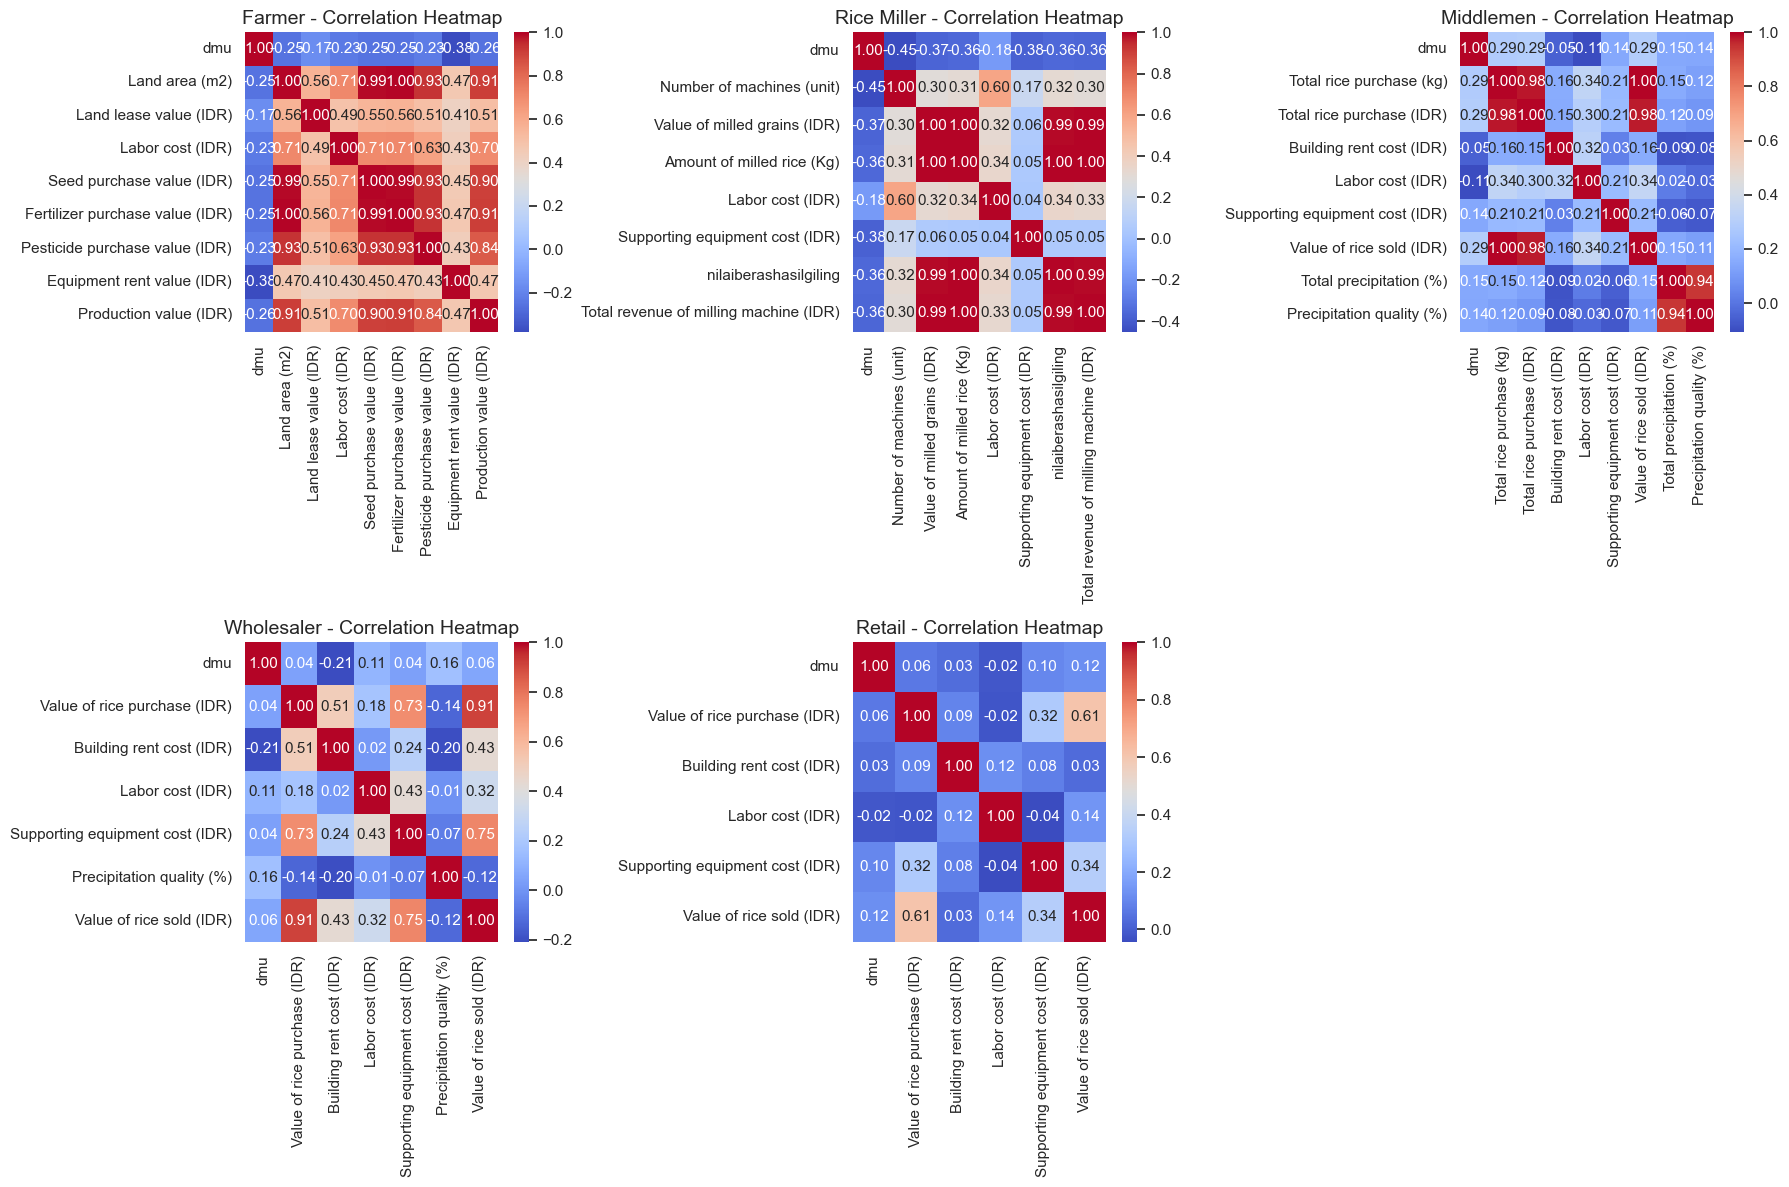

In [37]:
dataframes = {
    'Farmer': farmer,
    'Rice Miller': rice_miller,
    'Middlemen': middlemen,
    'Wholesaler': wholesaler,
    'Retail': retail
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, df) in enumerate(dataframes.items()):
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[idx])
    axes[idx].set_title(f'{name} - Correlation Heatmap')

# Hide the extra subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

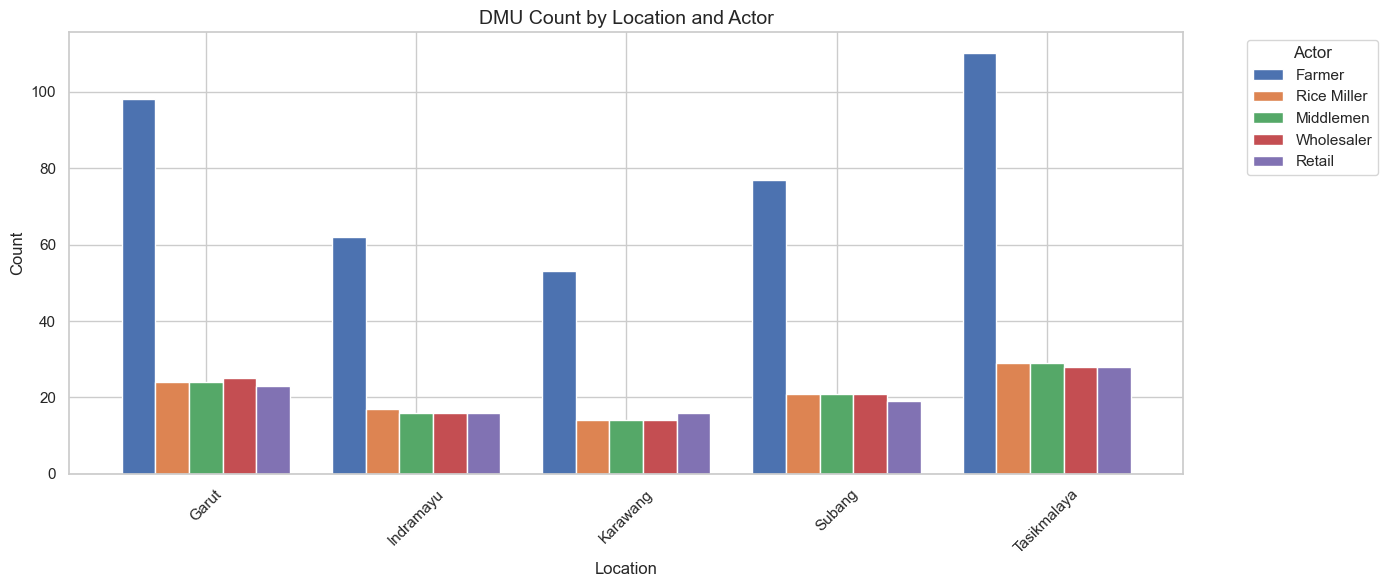

In [38]:
fig, axes = plt.subplots(1, 1, figsize=(14, 6))

# Create a dictionary to store counts for each location and actor
location_data = {}
for location in farmer['Location'].unique():
    location_data[location] = {}
    for name, df in dataframes.items():
        location_data[location][name] = len(df[df['Location'] == location])

# Convert to DataFrame for easier plotting
location_df = pd.DataFrame(location_data).T

# Plot grouped bar chart
location_df.plot(kind='bar', ax=axes, width=0.8)
axes.set_title('DMU Count by Location and Actor')
axes.set_xlabel('Location')
axes.set_ylabel('Count')
axes.legend(title='Actor', bbox_to_anchor=(1.05, 1), loc='upper left')
axes.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [39]:
farmer.groupby('Location')['Production value (IDR)'].mean().values


array([1.87460102e+07, 5.57480645e+07, 1.09004755e+08, 4.20194090e+07,
       2.02044455e+07])

In [40]:
data = [
  farmer.groupby('Location')['Production value (IDR)'].mean().values,
  rice_miller.groupby('Location')['Value of milled grains (IDR)'].mean().values,
  rice_miller.groupby('Location')['nilaiberashasilgiling'].mean().values,
  middlemen.groupby('Location')['Total rice purchase (IDR)'].mean().values,
  middlemen.groupby('Location')['Value of rice sold (IDR)'].mean().values,
  wholesaler.groupby('Location')['Value of rice purchase (IDR)'].mean().values,
  wholesaler.groupby('Location')['Value of rice sold (IDR)'].mean().values,
  retail.groupby('Location')['Value of rice purchase (IDR)'].mean().values,
  retail.groupby('Location')['Value of rice sold (IDR)'].mean().values,
]

# Create DataFrame with headers
price_spread = pd.DataFrame(data)
price_spread = price_spread.T
price_spread.columns = ["Farmer Sell", "Rice Miller Purchase", "Rice Miller Sell", "Middlemen Purchase", "Middlemen Sell", "Wholesaler Purchase", "Wholesaler Sell", "Retail Purchase", "Retail Sell"]
price_spread.insert(loc=0, column='Locations', value=['Garut', 'Indramayu', 'Karawang', 'Subang', 'Sumedang'])
price_spread


,Locations,Farmer Sell,Rice Miller Purchase,Rice Miller Sell,Middlemen Purchase,Middlemen Sell,Wholesaler Purchase,Wholesaler Sell,Retail Purchase,Retail Sell
0,Garut,1.874601e+07,1.061021e+08,1.271632e+08,3.906833e+07,3.885667e+07,1.153200e+08,1.175160e+08,2.496087e+06,3.215217e+06
1,Indramayu,5.574806e+07,8.555159e+08,1.046645e+09,1.477344e+08,1.805938e+08,1.496625e+09,2.315038e+09,2.294844e+06,2.770750e+06
2,Karawang,1.090048e+08,1.556500e+08,1.536759e+08,7.542500e+07,8.886071e+07,2.748071e+08,3.696071e+08,2.485312e+06,2.837500e+06
3,Subang,4.201941e+07,2.005143e+08,2.509387e+08,1.247833e+08,1.590848e+08,1.377857e+08,2.410937e+08,2.307237e+06,2.696053e+06
4,Sumedang,2.020445e+07,1.117659e+08,1.219328e+08,5.160522e+07,5.214207e+07,2.598993e+08,6.112525e+08,2.579375e+06,2.973393e+06


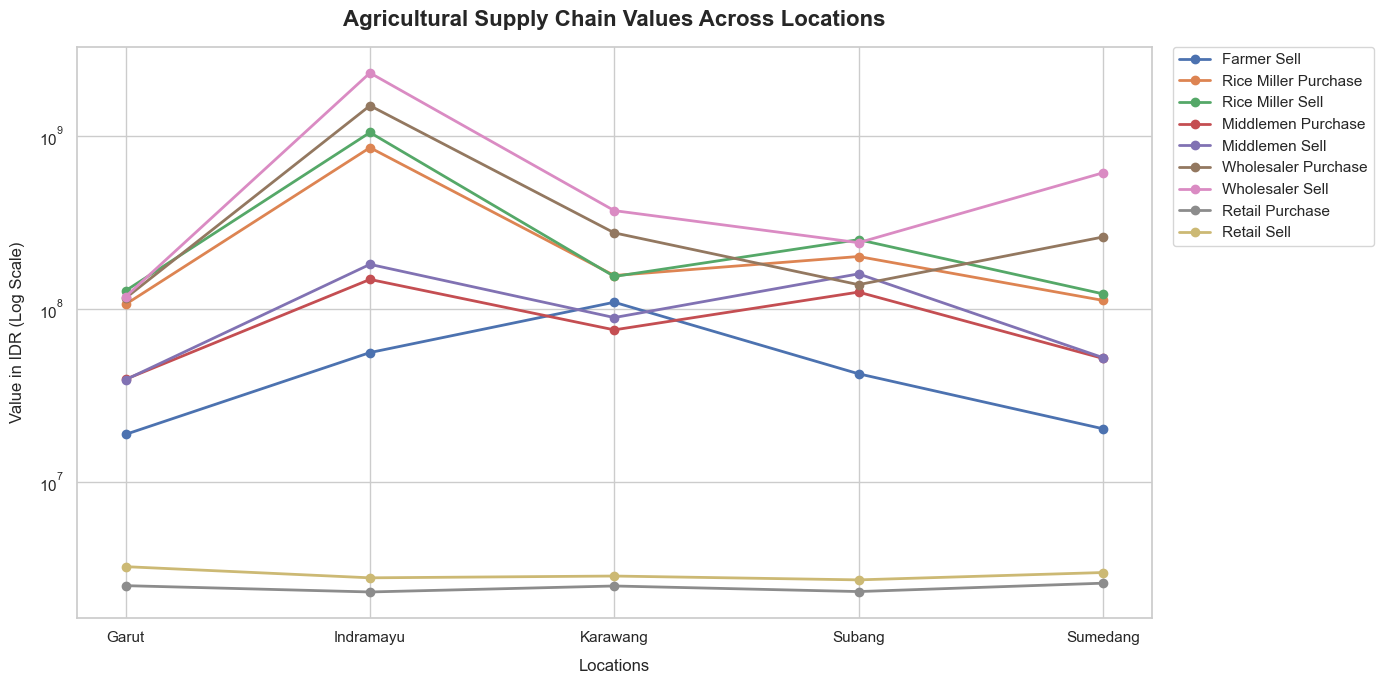

In [41]:
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 3. Loop through columns and plot each line
for column in price_spread.columns:
    if column != 'Locations':
        plt.plot(price_spread['Locations'], price_spread[column], marker='o', linewidth=2, label=column)

# 4. Styling adjustments
plt.title('Agricultural Supply Chain Values Across Locations', fontsize=16, pad=15, weight='bold')
plt.xlabel('Locations', fontsize=12, labelpad=10)
plt.ylabel('Value in IDR (Log Scale)', fontsize=12, labelpad=10)

# Use Logarithmic scale because of the massive difference between Retail and Wholesaler values
plt.yscale('log')

# Place legend cleanly outside the main frame
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize=11)
plt.tight_layout()

plt.show()

In [42]:
price_spread

,Locations,Farmer Sell,Rice Miller Purchase,Rice Miller Sell,Middlemen Purchase,Middlemen Sell,Wholesaler Purchase,Wholesaler Sell,Retail Purchase,Retail Sell
0,Garut,1.874601e+07,1.061021e+08,1.271632e+08,3.906833e+07,3.885667e+07,1.153200e+08,1.175160e+08,2.496087e+06,3.215217e+06
1,Indramayu,5.574806e+07,8.555159e+08,1.046645e+09,1.477344e+08,1.805938e+08,1.496625e+09,2.315038e+09,2.294844e+06,2.770750e+06
2,Karawang,1.090048e+08,1.556500e+08,1.536759e+08,7.542500e+07,8.886071e+07,2.748071e+08,3.696071e+08,2.485312e+06,2.837500e+06
3,Subang,4.201941e+07,2.005143e+08,2.509387e+08,1.247833e+08,1.590848e+08,1.377857e+08,2.410937e+08,2.307237e+06,2.696053e+06
4,Sumedang,2.020445e+07,1.117659e+08,1.219328e+08,5.160522e+07,5.214207e+07,2.598993e+08,6.112525e+08,2.579375e+06,2.973393e+06


   Locations  Rice Miller Margin  Middlemen Margin  Wholesaler Margin  Retail Margin
0      Garut        2.106111e+07     -2.116667e+05       2.196000e+06  719130.434783
1  Indramayu        1.911296e+08      3.285938e+07       8.184125e+08  475906.250000
2   Karawang       -1.974050e+06      1.343571e+07       9.480000e+07  352187.500000
3     Subang        5.042437e+07      3.430143e+07       1.033080e+08  388815.789474
4   Sumedang        1.016693e+07      5.368455e+05       3.513532e+08  394017.857143


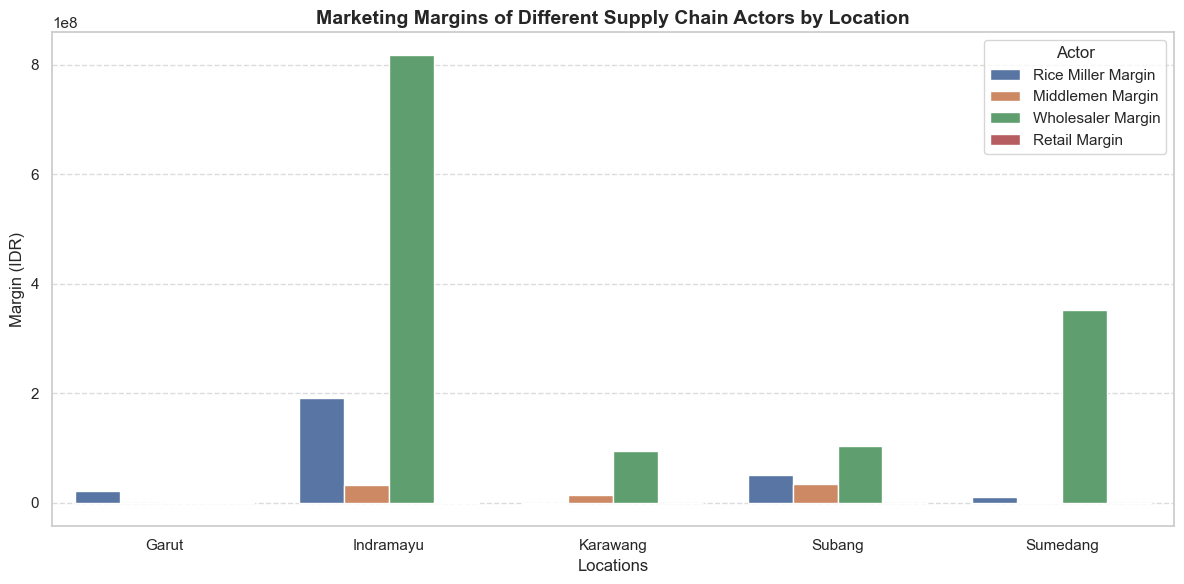

In [43]:
# Calculate marketing margins (Sell - Purchase)
price_spread['Rice Miller Margin'] = price_spread['Rice Miller Sell'] - price_spread['Rice Miller Purchase']
price_spread['Middlemen Margin'] = price_spread['Middlemen Sell'] - price_spread['Middlemen Purchase']
price_spread['Wholesaler Margin'] = price_spread['Wholesaler Sell'] - price_spread['Wholesaler Purchase']
price_spread['Retail Margin'] = price_spread['Retail Sell'] - price_spread['Retail Purchase']

margin_cols = ['Locations', 'Rice Miller Margin', 'Middlemen Margin', 'Wholesaler Margin', 'Retail Margin']
print(price_spread[margin_cols].to_string())

# Let's melt the dataframe for plotting
df_melted = price_spread.melt(id_vars='Locations', value_vars=['Rice Miller Margin', 'Middlemen Margin', 'Wholesaler Margin', 'Retail Margin'],
                    var_name='Actor', value_name='Margin (IDR)')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Locations', y='Margin (IDR)', hue='Actor')
plt.title('Marketing Margins of Different Supply Chain Actors by Location', fontsize=14, weight='bold')
plt.ylabel('Margin (IDR)')
plt.xlabel('Locations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Ulil Uzi Vert


In [44]:
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Load data dan hitung metrik aggregat per regency
wholesaler = pd.read_csv("wholesaler.csv")
wholesaler['roi_ratio'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']

# Aggregasi data finansial per kabupaten
geo_stats = wholesaler.groupby('Location').agg(
    mean_roi=('roi_ratio', 'mean'),
    max_roi=('roi_ratio', 'max'),
    total_volume_idr=('Value of rice purchase (IDR)', 'sum'),
    transaction_count=('dmu', 'count')
).reset_index()

# 2. Definisikan koordinat centroid resmi Kabupaten terkait
geo_centroids = {
    'Garut': {'lat': -7.2278, 'lon': 107.9087},
    'Indramayu': {'lat': -6.3264, 'lon': 108.3242},
    'Karawang': {'lat': -6.3227, 'lon': 107.3376},
    'Subang': {'lat': -6.5590, 'lon': 107.7583},
    'Tasikmalaya': {'lat': -7.3502, 'lon': 108.2163}
}

# Mapping koordinat ke dataframe
geo_stats['lat'] = geo_stats['Location'].map(lambda x: geo_centroids[x]['lat'] if x in geo_centroids else np.nan)
geo_stats['lon'] = geo_stats['Location'].map(lambda x: geo_centroids[x]['lon'] if x in geo_centroids else np.nan)

# 3. Bangun visualisasi spasial interaktif
fig = px.scatter_mapbox(
    geo_stats,
    lat="lat",
    lon="lon",
    color="mean_roi",
    size="max_roi",
    color_continuous_scale=px.colors.sequential.Reds,
    size_max=40,
    zoom=8,
    hover_name="Location",
    hover_data={
        "mean_roi": ":.2f",
        "max_roi": ":.2f",
        "total_volume_idr": ":,.0f",
        "transaction_count": True,
        "lat": False,
        "lon": False
    },
    title="Peta Disparitas Spasial: Deteksi Anomali Margin Wholesaler Beras Jawa Barat",
    labels={
        "mean_roi": "Rata-rata ROI",
        "max_roi": "Semburan ROI Maksimum",
        "Location": "Kabupaten"
    }
)

# Konfigurasi layout peta profesional menggunakan style open-street-map
fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":50,"l":0,"b":0},
    title_font_size=18,
    title_x=0.02
)

# Menampilkan atau menyimpan output
fig.write_html("spatial_price_disparity_map.html")
fig.show()

C:\Users\apits\AppData\Local\Temp\ipykernel_18768\4031182425.py:31: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


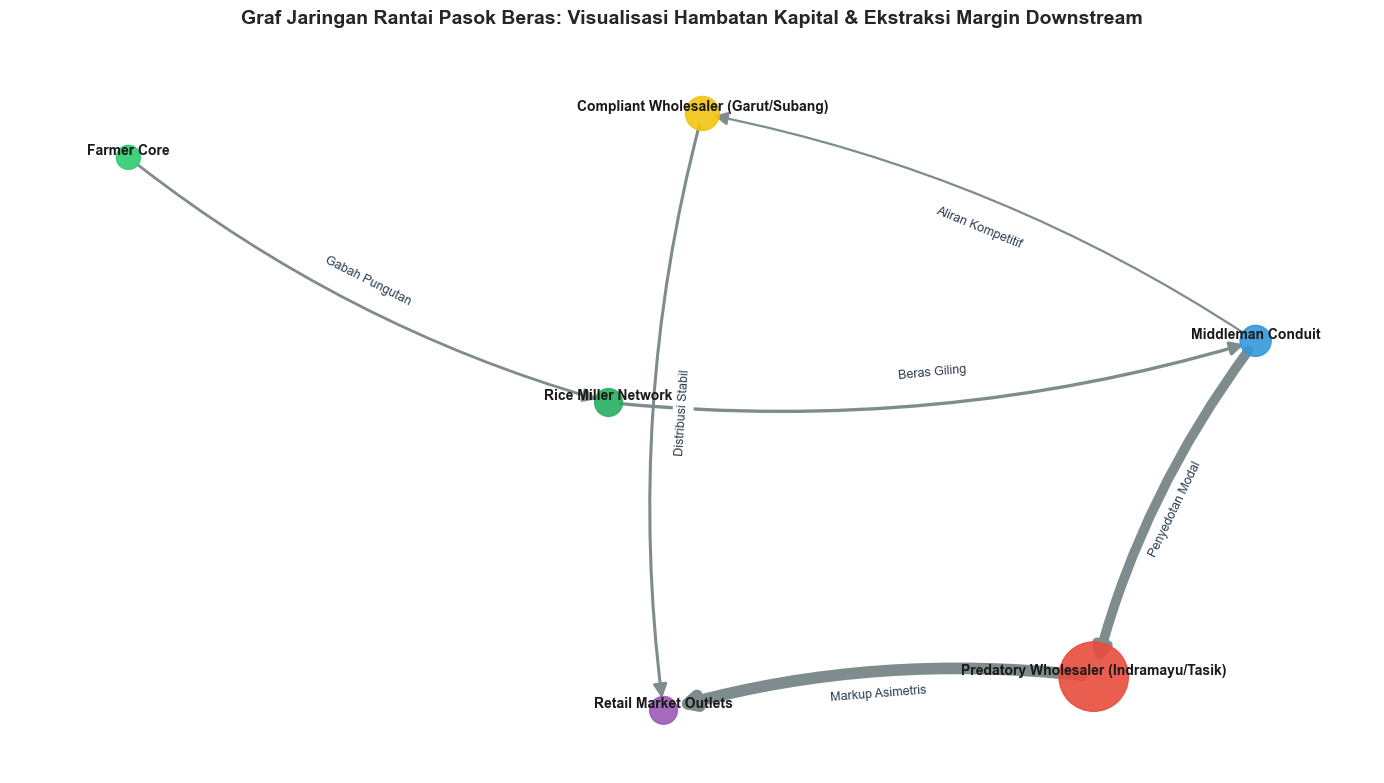

In [45]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 1. Inisialisasi Directed Graph
G = nx.DiGraph()

# 2. Definisikan struktur node komparatif berdasarkan mean ROI per tier dari data analitik kita
# Node format: (Nama_Node, {atribut})
nodes_definition = [
    ('Farmer Core', {'tier': 'Upstream', 'size': 300, 'color': '#2ecc71'}),
    ('Rice Miller Network', {'tier': 'Upstream', 'size': 400, 'color': '#27ae60'}),
    ('Middleman Conduit', {'tier': 'Logistics', 'size': 500, 'color': '#3498db'}),
    ('Compliant Wholesaler (Garut/Subang)', {'tier': 'Downstream_Normal', 'size': 600, 'color': '#f1c40f'}),
    ('Predatory Wholesaler (Indramayu/Tasik)', {'tier': 'Downstream_Risk', 'size': 2500, 'color': '#e74c3c'}),
    ('Retail Market Outlets', {'tier': 'Downstream_Normal', 'size': 400, 'color': '#9b59b6'})
]

G.add_nodes_from(nodes_definition)

# 3. Bangun keterkaitan distribusi berarah (Aliran Fisik & Finansial)
edges_definition = [
    ('Farmer Core', 'Rice Miller Network', {'weight': 1.0, 'label': 'Gabah Pungutan'}),
    ('Rice Miller Network', 'Middleman Conduit', {'weight': 1.2, 'label': 'Beras Giling'}),
    ('Middleman Conduit', 'Compliant Wholesaler (Garut/Subang)', {'weight': 0.8, 'label': 'Aliran Kompetitif'}),
    ('Middleman Conduit', 'Predatory Wholesaler (Indramayu/Tasik)', {'weight': 3.5, 'label': 'Penyedotan Modal'}),
    ('Compliant Wholesaler (Garut/Subang)', 'Retail Market Outlets', {'weight': 1.1, 'label': 'Distribusi Stabil'}),
    ('Predatory Wholesaler (Indramayu/Tasik)', 'Retail Market Outlets', {'weight': 4.2, 'label': 'Markup Asimetris'})
]

for src, dst, attrs in edges_definition:
    G.add_edge(src, dst, **attrs)

# 4. Rendering Grafik Menggunakan Struktur Tata Letak Multipartite/Spring
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(G, seed=101, k=1.5)

# Ekstrak atribut untuk parameter plotting
node_sizes = [data['size'] for node, data in G.nodes(data=True)]
node_colors = [data['color'] for node, data in G.nodes(data=True)]
edge_widths = [data['weight'] * 2 for src, dst, data in G.edges(data=True)]

# Draw elemen komparatif graf
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='#7f8c8d', arrowsize=20, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', verticalalignment='bottom')

# Draw label pada jalur distribusi
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='#2c3e50')

plt.title("Graf Jaringan Rantai Pasok Beras: Visualisasi Hambatan Kapital & Ekstraksi Margin Downstream", fontsize=14, weight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.savefig("supply_chain_network_graph.png", dpi=300)
plt.show()

In [47]:
import plotly.graph_objects as go

# 1. Definisikan Label Seluruh Node Rantai Pasok
# Indeks array ini merepresentasikan ID dari Node untuk Source & Target
node_labels = [
    "[0. Produksi Petani Hulu]",           # Node 0
    "[1. Penggilingan Padi (Miller)]",    # Node 1
    "[2. Kolektor Logistik (Middleman)]", # Node 2
    "[3. Wholesaler Kompetitif (Garut)]",  # Node 3
    "[4. Wholesaler Eksploitatif (Indramayu/Tasik)]", # Node 4
    "[5. Pasar Retail & Konsumen Akhir]"   # Node 5
]

# Definisikan warna representatif untuk setiap node korelasi
node_colors = [
    "#2ecc71", # Petani (Hijau Lestari)
    "#27ae60", # Penggilingan (Hijau Tua)
    "#3498db", # Middleman (Biru Logistik)
    "#f1c40f", # Wholesaler Normal (Kuning Kompetitif)
    "#e74c3c", # Wholesaler Anomali (Merah Bahaya)
    "#9b59b6"  # Retail (Ungu Retail)
]

# 2. Konfigurasi Aliran Nilai (Flow Matrix)
# Source -> Target dengan besaran bobot aliran ekonomi (Value)
sources = [0, 1, 2, 2, 3, 4]  # ID Node asal
targets = [1, 2, 3, 4, 5, 5]  # ID Node tujuan
values  = [100, 98, 40, 58, 45, 240] # Nilai kumulatif (Merefleksikan ledakan volume nilai di Wholesaler Eksploitatif)

# Warna link aliran (menggunakan transparansi rgba untuk keindahan visualisasi)
link_colors = [
    "rgba(46, 204, 113, 0.4)",  # Petani -> Miller
    "rgba(39, 174, 96, 0.4)",   # Miller -> Middleman
    "rgba(52, 152, 219, 0.4)",  # Middleman -> Wholesaler Normal
    "rgba(231, 76, 60, 0.5)",   # Middleman -> Wholesaler Eksploitatif (Sorotan Utama)
    "rgba(241, 196, 152, 0.4)", # Wholesaler Normal -> Retail
    "rgba(231, 76, 60, 0.7)"    # Wholesaler Eksploitatif -> Retail (Ledakan Nilai Ekstraksi)
]

# 3. Konstruksi Komponen Objek Sankey Plotly
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = node_labels,
      color = node_colors
    ),
    link = dict(
      source = sources,
      target = targets,
      value = values,
      color = link_colors,
      hovertemplate = 'Aliran dari %{source.label} ke %{target.label}<br>Magnitudo Nilai Ekonomi: %{value}<extra></extra>'
    )
)])

# Konfigurasi layout interaktif dashboard presentation
fig.update_layout(
    title_text="Diagram Sankey Interaktif: Pemetaan Kebocoran Nilai Finansial & Multiplier Efek pada Komoditas Beras",
    font_size=12,
    width=1100,
    height=600,
    title_font_size=16,
    title_x=0.01
)

# Eksport hasil ke HTML interaktif mandiri
fig.write_html("interactive_sankey_diagram.html")
fig.show()

# Anomaly


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# 2. Harmonize and calculate unit prices/proxies for each actor tier
# Farmer: Production Value / Estimated Yield (We can use a proxy metric or look at value density)
farmer['price_metric'] = farmer['Production value (IDR)'] / farmer['Land area (m2)']
farmer['Actor_Type'] = 'Farmer'

rice_miller['price_metric'] = rice_miller['nilaiberashasilgiling'] / rice_miller['Amount of milled rice (Kg)']
rice_miller['Actor_Type'] = 'Rice Miller'

middlemen['price_metric'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']
middlemen['Actor_Type'] = 'Middleman'

wholesaler['price_metric'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']
wholesaler['Actor_Type'] = 'Wholesaler'

retail['price_metric'] = retail['Value of rice sold (IDR)'] / retail['Value of rice purchase (IDR)']
retail['Actor_Type'] = 'Retail'

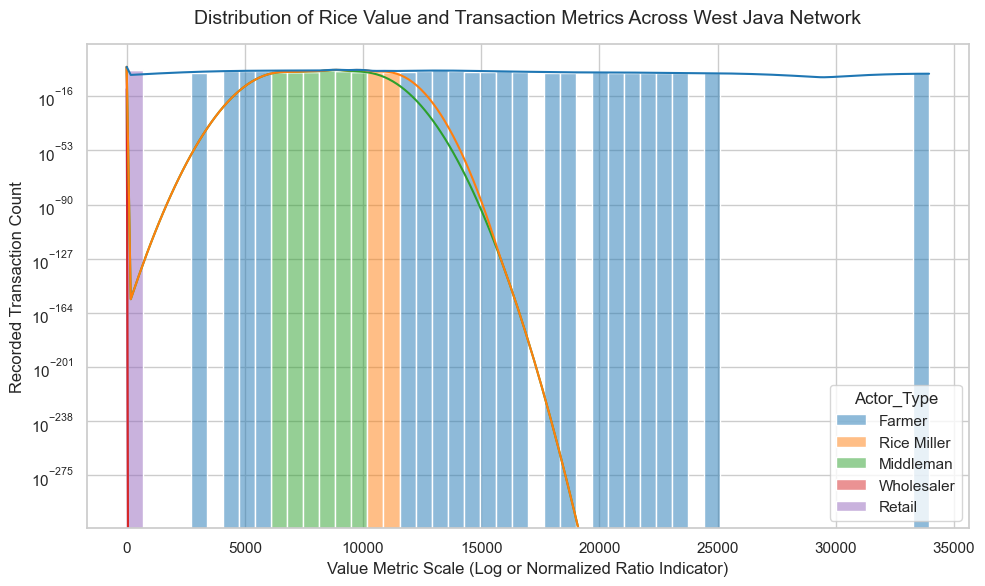

In [5]:
# 3. Combine into a master analytical dataframe for cross-sectional plotting
# We keep only the metrics common across all actors for this visual phase
columns_to_keep = ['Location', 'Actor_Type', 'price_metric']
master_df = pd.concat([
    farmer[columns_to_keep],
    rice_miller[columns_to_keep],
    middlemen[columns_to_keep],
    wholesaler[columns_to_keep],
    retail[columns_to_keep]
], ignore_index=True)

# Rename 'Location' to 'Regency' for clarity in the presentation
master_df.rename(columns={'Location': 'Regency'}, inplace=True)

# Clean up infinite values or extreme zeros caused by unentered data
master_df = master_df[np.isfinite(master_df['price_metric']) & (master_df['price_metric'] > 0)]

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# =====================================================================
# CHART 1: HISTOGRAM OF ECONOMIC VALUE METRICS
# =====================================================================
plt.figure(figsize=(10, 6))
sns.histplot(data=master_df, x='price_metric', hue='Actor_Type', kde=True, multiple="stack", palette="tab10", bins=50)

plt.title('Distribution of Rice Value and Transaction Metrics Across West Java Network', pad=15)
plt.xlabel('Value Metric Scale (Log or Normalized Ratio Indicator)')
plt.ylabel('Recorded Transaction Count')
plt.yscale('log') # Log scale helps handle the massive gap between small farms and macro wholesalers
plt.tight_layout()
plt.show()

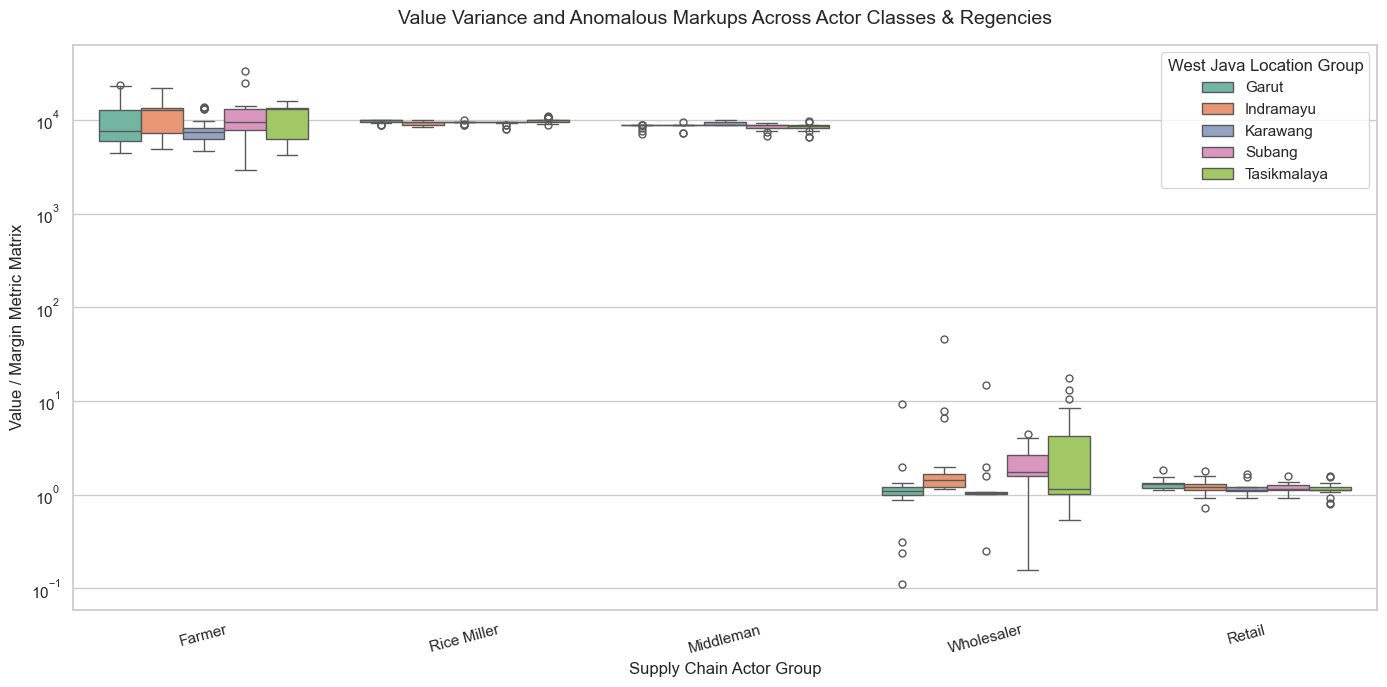

In [6]:
# =====================================================================
# CHART 2: REGIONAL BOX PLOT FOR ANOMALY IDENTIFICATION
# =====================================================================
plt.figure(figsize=(14, 7))
actor_order = ['Farmer', 'Rice Miller', 'Middleman', 'Wholesaler', 'Retail']

sns.boxplot(
    data=master_df, 
    x='Actor_Type', 
    y='price_metric', 
    hue='Regency', 
    order=actor_order,
    palette='Set2',
    fliersize=5
)

plt.title('Value Variance and Anomalous Markups Across Actor Classes & Regencies', pad=15)
plt.xlabel('Supply Chain Actor Group')
plt.ylabel('Value / Margin Metric Matrix')
plt.yscale('log') # Kept to maintain scalability across different unit columns
plt.xticks(rotation=15)
plt.legend(title='West Java Location Group', loc='upper right')
plt.tight_layout()
plt.show()

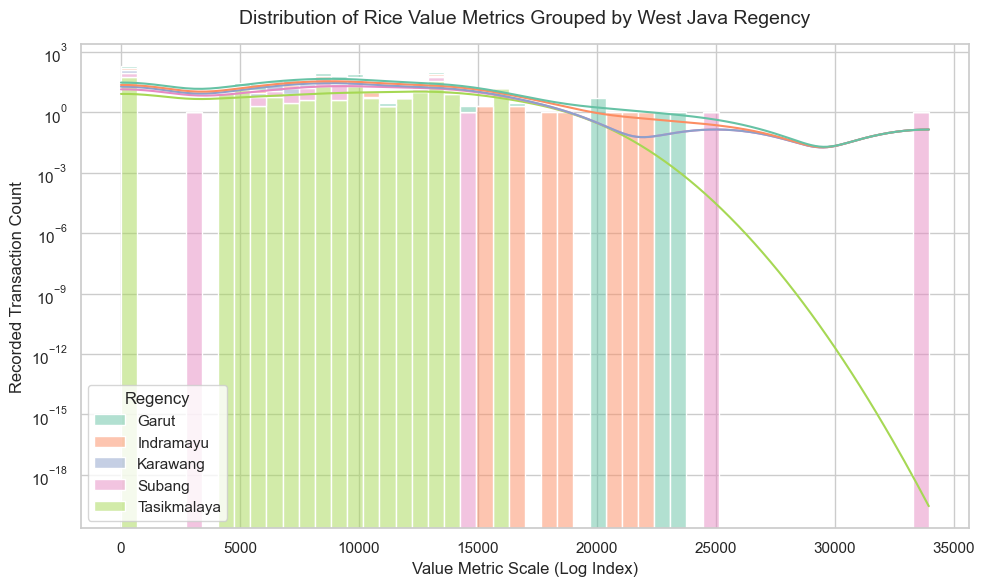

In [15]:
# =====================================================================
# REVISED CHART 1: HISTOGRAM (Grouped by Regency)
# =====================================================================
plt.figure(figsize=(10, 6))
sns.histplot(data=master_df, x='price_metric', hue='Regency', kde=True, multiple="stack", palette="Set2", bins=50)

plt.title('Distribution of Rice Value Metrics Grouped by West Java Regency', pad=15)
plt.xlabel('Value Metric Scale (Log Index)')
plt.ylabel('Recorded Transaction Count')
plt.yscale('log')
plt.tight_layout()
plt.show()

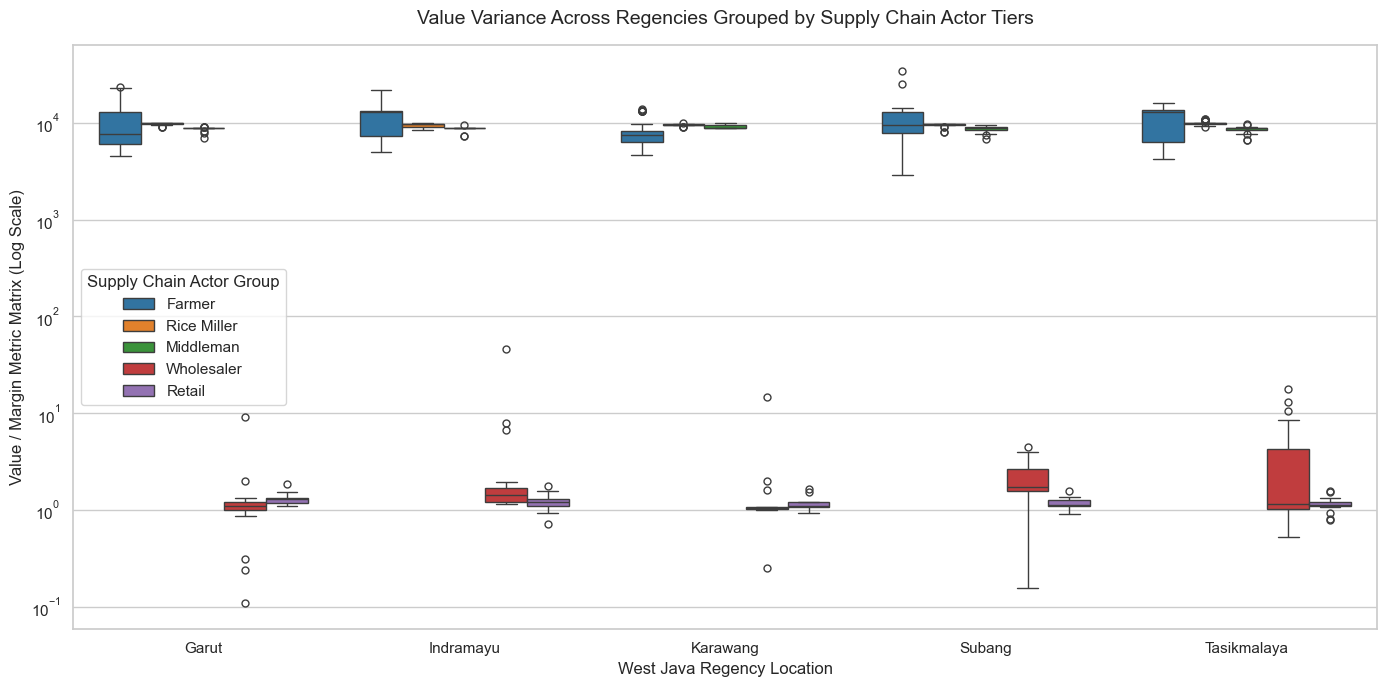

In [18]:
# =====================================================================
# REVISED CHART 2: BOX PLOT (X-Axis = Regency, Hue = Actor Type)
# =====================================================================
plt.figure(figsize=(14, 7))

# Establish strict alphabetical order for locations and logical supply chain flow for actors
regency_order = sorted(master_df['Regency'].unique())
actor_order = ['Farmer', 'Rice Miller', 'Middleman', 'Wholesaler', 'Retail']

sns.boxplot(
    data=master_df, 
    x='Regency', 
    y='price_metric', 
    hue='Actor_Type', 
    order=regency_order,
    hue_order=actor_order,
    palette='tab10',
    fliersize=5
)

plt.title('Value Variance Across Regencies Grouped by Supply Chain Actor Tiers', pad=15)
plt.xlabel('West Java Regency Location')
plt.ylabel('Value / Margin Metric Matrix (Log Scale)')
plt.yscale('log')
plt.legend(title='Supply Chain Actor Group', loc='best')
plt.tight_layout()
plt.show()

In [20]:
# =====================================================================
# PHYSICAL SCALE ANALYSIS (Middlemen)
# =====================================================================
middlemen['unit_price_sold'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']
middlemen['log_volume_kg'] = np.log1p(middlemen['Total rice purchase (kg)'])

# Feature: Ratio of price to log volume
middlemen['physical_scale_index'] = middlemen['unit_price_sold'] / middlemen['log_volume_kg']

# =====================================================================
# CAPITAL SCALE ANALYSIS (Wholesalers)
# =====================================================================
wholesaler['roi_multiplier'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']
wholesaler['log_capital_purchase'] = np.log10(wholesaler['Value of rice purchase (IDR)'])

# Feature: ROI relative to the size of the capital deployed
wholesaler['capital_scale_index'] = wholesaler['roi_multiplier'] / wholesaler['log_capital_purchase']

# 2. Extract Top 5 Exploitative Capital Scale Anomalies for the Report Table
top_wholesaler_anomalies = wholesaler.sort_values(by='capital_scale_index', ascending=False).head(5)

print("=== CRITICAL CAPITAL SCALE ANOMALIES (WHOLESALER) ===")
top_wholesaler_anomalies[['Location', 'Value of rice purchase (IDR)', 'Value of rice sold (IDR)', 'roi_multiplier']]

=== CRITICAL CAPITAL SCALE ANOMALIES (WHOLESALER) ===


,Location,Value of rice purchase (IDR),Value of rice sold (IDR),roi_multiplier
37,Indramayu,114000000.0,5.292000e+09,46.421053
88,Tasikmalaya,114000000.0,2.016000e+09,17.684211
46,Karawang,114000000.0,1.692000e+09,14.842105
87,Tasikmalaya,114000000.0,1.504000e+09,13.192982
96,Tasikmalaya,114000000.0,1.200000e+09,10.526316


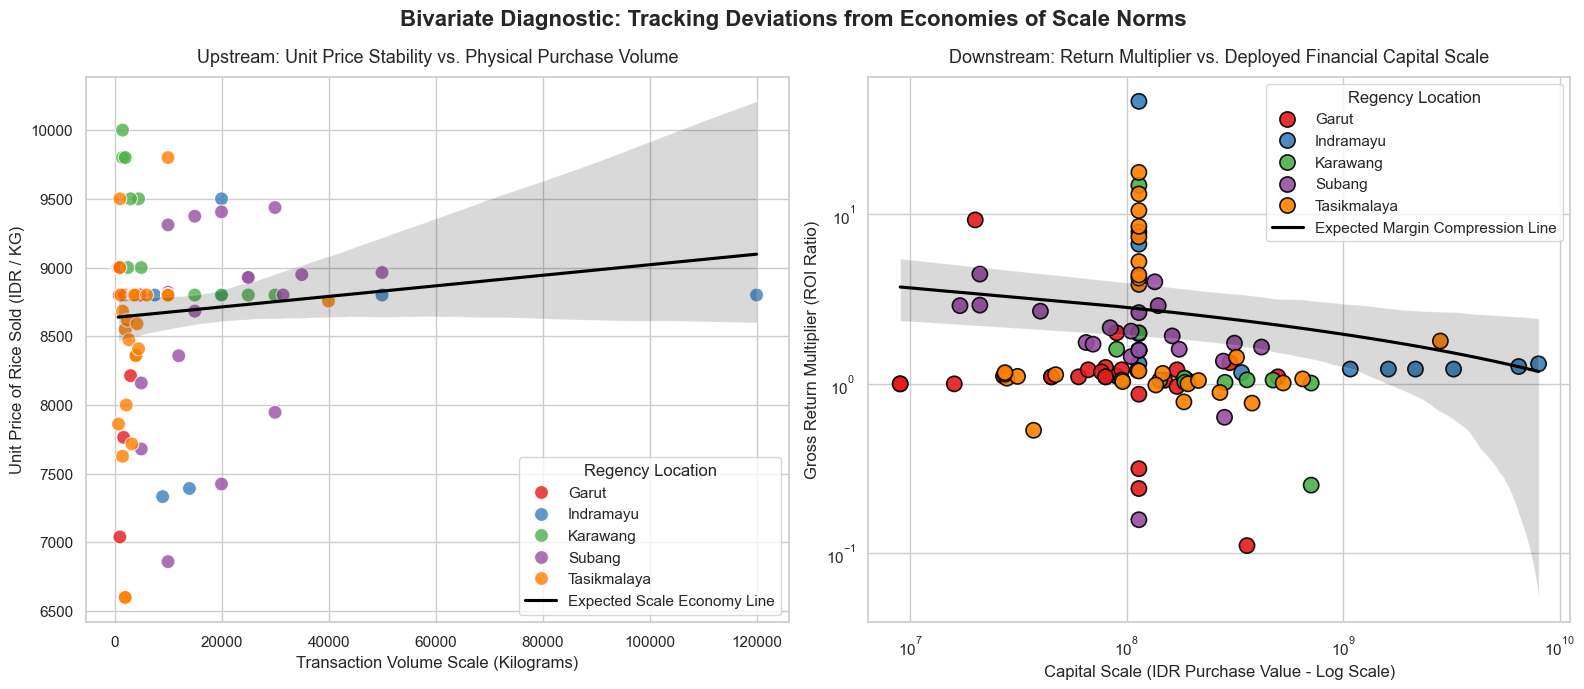

In [23]:
middlemen['unit_price_sold'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']

# Wholesaler (Capital Scale)
wholesaler['roi_multiplier'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']

# Set up side-by-side plotting canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 13})

# =====================================================================
# PANEL 1: UPSTREAM PHYSICAL SCALE ECONOMY (Middlemen)
# =====================================================================
sns.scatterplot(
    data=middlemen,
    x='Total rice purchase (kg)',
    y='unit_price_sold',
    hue='Location',
    palette='Set1',
    s=100,
    alpha=0.8,
    ax=axes[0]
)
# Add a trendline to show the "Volume Norm" baseline
sns.regplot(
    data=middlemen,
    x='Total rice purchase (kg)',
    y='unit_price_sold',
    scatter=False,
    color='black',
    marker='--',
    ax=axes[0],
    label='Expected Scale Economy Line'
)
axes[0].set_title('Upstream: Unit Price Stability vs. Physical Purchase Volume', pad=10)
axes[0].set_xlabel('Transaction Volume Scale (Kilograms)')
axes[0].set_ylabel('Unit Price of Rice Sold (IDR / KG)')
axes[0].legend(title='Regency Location')

# =====================================================================
# PANEL 2: DOWNSTREAM CAPITAL SCALE ECONOMY (Wholesaler)
# =====================================================================
sns.scatterplot(
    data=wholesaler,
    x='Value of rice purchase (IDR)',
    y='roi_multiplier',
    hue='Location',
    palette='Set1',
    s=120,
    alpha=0.9,
    edgecolor='black',
    linewidth=1.2,
    ax=axes[1]
)
# Add a trendline to illustrate the systemic deviation from scale norms
sns.regplot(
    data=wholesaler,
    x='Value of rice purchase (IDR)',
    y='roi_multiplier',
    scatter=False,
    color='black',
    marker='--',
    logx=True, # Logarithmic fit captures power-law scaling accurately
    ax=axes[1],
    label='Expected Margin Compression Line'
)

axes[1].set_title('Downstream: Return Multiplier vs. Deployed Financial Capital Scale', pad=10)
axes[1].set_xlabel('Capital Scale (IDR Purchase Value - Log Scale)')
axes[1].set_ylabel('Gross Return Multiplier (ROI Ratio)')
axes[1].set_xscale('log') # Essential due to the multi-billion IDR variance
axes[1].set_yscale('log') # Essential to keep the 46.4x outlier from squishing the data
axes[1].legend(title='Regency Location')

plt.suptitle('Bivariate Diagnostic: Tracking Deviations from Economies of Scale Norms', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\apits\AppData\Local\Temp\ipykernel_18768\3291207303.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(tier_order, rotation=15)
C:\Users\apits\AppData\Local\Temp\ipykernel_18768\3291207303.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(tier_order, rotation=15)


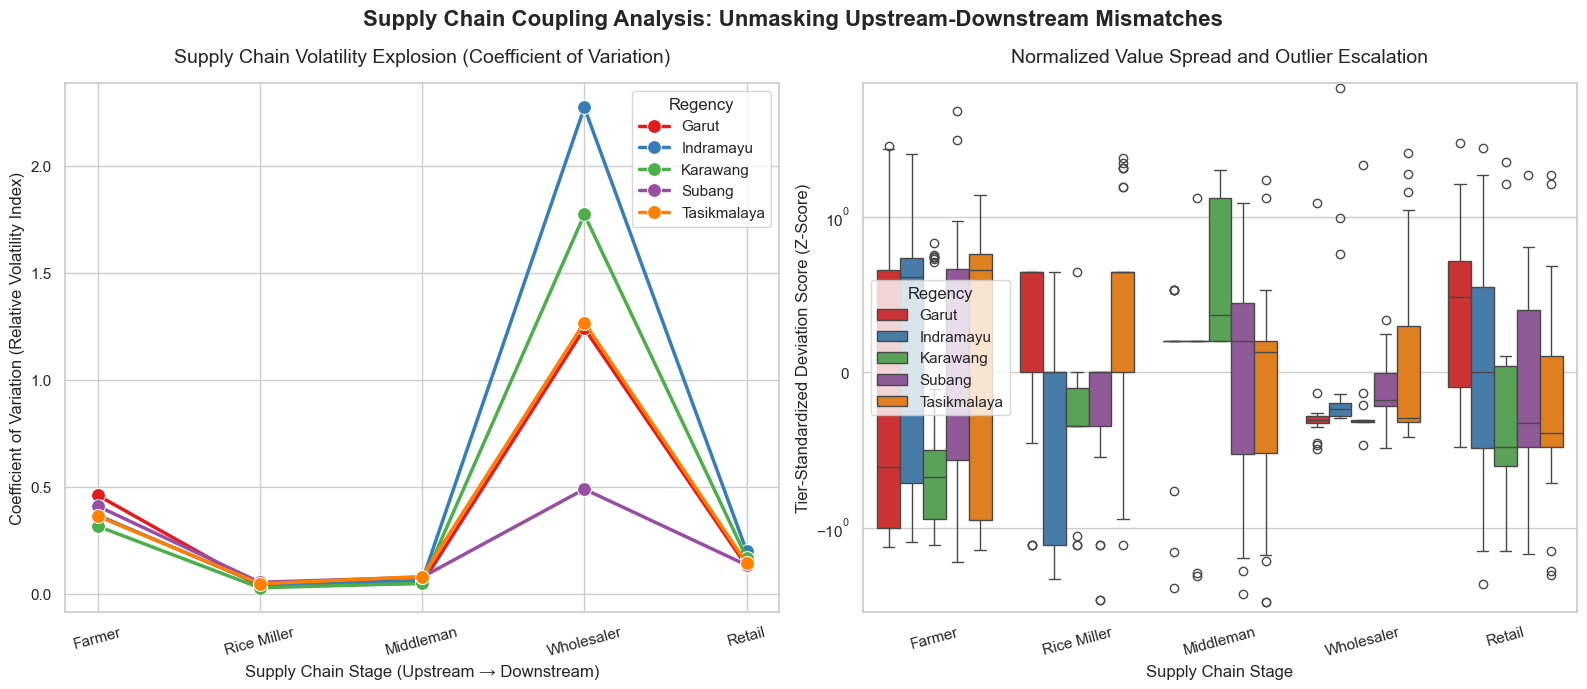

In [24]:
# 2. Re-establish Standardized Target Performance Metrics
farmer['metric'] = farmer['Production value (IDR)'] / farmer['Land area (m2)']
rice_miller['metric'] = rice_miller['nilaiberashasilgiling'] / rice_miller['Amount of milled rice (Kg)']
middlemen['metric'] = middlemen['Value of rice sold (IDR)'] / middlemen['Total rice purchase (kg)']
wholesaler['metric'] = wholesaler['Value of rice sold (IDR)'] / wholesaler['Value of rice purchase (IDR)']
retail['metric'] = retail['Value of rice sold (IDR)'] / retail['Value of rice purchase (IDR)']

tiers = {
    'Farmer': farmer,
    'Rice Miller': rice_miller,
    'Middleman': middlemen,
    'Wholesaler': wholesaler,
    'Retail': retail
}

# 3. Compute Coefficient of Variation (CV = std / mean) for Volatility Analysis
cv_data = []
for tier_name, df in tiers.items():
    loc_col = 'Location' if 'Location' in df.columns else 'Regency'
    grouped = df.groupby(loc_col)['metric'].agg(['mean', 'std']).reset_index()
    grouped['CV'] = grouped['std'] / grouped['mean']
    grouped['Tier'] = tier_name
    grouped.rename(columns={loc_col: 'Regency'}, inplace=True)
    cv_data.append(grouped[['Regency', 'Tier', 'CV']])
cv_df = pd.concat(cv_data, ignore_index=True)

# 4. Compute Global Tier-Standardized Z-Scores to map Normalized Structural Spread
z_data = []
for tier_name, df in tiers.items():
    loc_col = 'Location' if 'Location' in df.columns else 'Regency'
    temp = df[[loc_col, 'metric']].copy()
    temp.rename(columns={loc_col: 'Regency'}, inplace=True)
    temp = temp[np.isfinite(temp['metric']) & (temp['metric'] > 0)]
    
    # Global tier standardization
    temp['z_score'] = (temp['metric'] - temp['metric'].mean()) / temp['metric'].std()
    temp['Tier'] = tier_name
    z_data.append(temp[['Regency', 'Tier', 'z_score']])
z_df = pd.concat(z_data, ignore_index=True)

# 5. Execute Dual-Panel Plotting Layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
tier_order = ['Farmer', 'Rice Miller', 'Middleman', 'Wholesaler', 'Retail']

# PANEL 1: Volatility Pipeline (Tracking CV across the supply chain flow)
sns.lineplot(data=cv_df, x='Tier', y='CV', hue='Regency', marker='o', markersize=10, linewidth=2.5, palette='Set1', sort=False, ax=axes[0])
axes[0].set_title('Supply Chain Volatility Explosion (Coefficient of Variation)', pad=15)
axes[0].set_xlabel('Supply Chain Stage (Upstream → Downstream)')
axes[0].set_ylabel('Coefficient of Variation (Relative Volatility Index)')
axes[0].set_xticklabels(tier_order, rotation=15)

# PANEL 2: Standardized Spread Variance (Symlog distribution mapping)
sns.boxplot(data=z_df, x='Tier', y='z_score', hue='Regency', order=tier_order, palette='Set1', fliersize=6, ax=axes[1])
axes[1].set_title('Normalized Value Spread and Outlier Escalation', pad=15)
axes[1].set_xlabel('Supply Chain Stage')
axes[1].set_ylabel('Tier-Standardized Deviation Score (Z-Score)')
axes[1].set_yscale('symlog', linthresh=1.0) # Symmetric log exposes extreme outliers alongside tight boxes
axes[1].set_xticklabels(tier_order, rotation=15)

plt.suptitle('Supply Chain Coupling Analysis: Unmasking Upstream-Downstream Mismatches', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Nganuin Data


In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

def normalize_tier_dataset(df, idr_cols, count_cols, pct_cols, engineered_metric_func, tier_name):
    """
    Executes an isolated robust normalization pipeline for a specific supply chain tier.
    """
    df_clean = df.copy()
    loc_col = 'Location' if 'Location' in df_clean.columns else 'Regency'
    
    # Step A: Compute the standardized base performance metric
    df_clean['raw_performance_metric'] = engineered_metric_func(df_clean)
    
    # Filter out mathematically invalid or dead rows
    df_clean = df_clean[np.isfinite(df_clean['raw_performance_metric']) & (df_clean['raw_performance_metric'] > 0)]
    
    # Step B: Apply Logarithmic Pre-Compression to highly skewed numeric columns
    for col in idr_cols + count_cols:
        if col in df_clean.columns:
            df_clean[f'log_{col}'] = np.log1p(df_clean[col])
            
    # Include our custom metric in log compression
    df_clean['log_performance_metric'] = np.log1p(df_clean['raw_performance_metric'])
    
    # Step C: Select columns intended as features for downstream machine learning models
    feature_cols = [f'log_{col}' for col in idr_cols + count_cols] + \
                   [col for col in pct_cols if col in df_clean.columns] + \
                   ['log_performance_metric']
    
    # Step D: Apply Outlier-Robust Scaler
    scaler = RobustScaler()
    scaled_features = scaler.fit_transform(df_clean[feature_cols])
    
    # Build clean output dataframe
    scaled_feature_names = [f'scaled_{col}' for col in feature_cols]
    scaled_df = pd.DataFrame(scaled_features, columns=scaled_feature_names, index=df_clean.index)
    
    # Retain metadata for report tracking and plotting
    scaled_df['Regency'] = df_clean[loc_col]
    scaled_df['Tier'] = tier_name
    scaled_df['Raw_Metric'] = df_clean['raw_performance_metric']
    
    return scaled_df

In [26]:
# =====================================================================
# RUN EXECUTIONS PER TIER WITH CUSTOM METRIC DEFINITIONS
# =====================================================================

# Farmer Normalization
farmer_scaled = normalize_tier_dataset(
    df=farmer,
    idr_cols=['Land lease value (IDR)', 'Labor cost (IDR)', 'Seed purchase value (IDR)', 'Fertilizer purchase value (IDR)', 'Pesticide purchase value (IDR)', 'Equipment rent value (IDR)', 'Production value (IDR)'],
    count_cols=['Land area (m2)'],
    pct_cols=[],
    engineered_metric_func=lambda d: d['Production value (IDR)'] / d['Land area (m2)'],
    tier_name='Farmer'
)

# Rice Miller Normalization
rice_miller_scaled = normalize_tier_dataset(
    df=rice_miller,
    idr_cols=['Value of milled grains (IDR)', 'Labor cost (IDR)', 'Supporting equipment cost (IDR)', 'nilaiberashasilgiling', 'Total revenue of milling machine (IDR)'],
    count_cols=['Amount of milled rice (Kg)', 'Number of machines (unit)'],
    pct_cols=[],
    engineered_metric_func=lambda d: d['nilaiberashasilgiling'] / d['Amount of milled rice (Kg)'],
    tier_name='Rice Miller'
)

# Middleman Normalization
middleman_scaled = normalize_tier_dataset(
    df=middlemen,
    idr_cols=['Total rice purchase (IDR)', 'Building rent cost (IDR)', 'Labor cost (IDR)', 'Supporting equipment cost (IDR)', 'Value of rice sold (IDR)'],
    count_cols=['Total rice purchase (kg)'],
    pct_cols=['Total precipitation (%)', 'Precipitation quality (%)'],
    engineered_metric_func=lambda d: d['Value of rice sold (IDR)'] / d['Total rice purchase (kg)'],
    tier_name='Middleman'
)

# Wholesaler Normalization
wholesaler_scaled = normalize_tier_dataset(
    df=wholesaler,
    idr_cols=['Value of rice purchase (IDR)', 'Building rent cost (IDR)', 'Labor cost (IDR)', 'Supporting equipment cost (IDR)', 'Value of rice sold (IDR)'],
    count_cols=[],
    pct_cols=['Precipitation quality (%)'],
    engineered_metric_func=lambda d: d['Value of rice sold (IDR)'] / d['Value of rice purchase (IDR)'],
    tier_name='Wholesaler'
)

# Retail Normalization
retail_scaled = normalize_tier_dataset(
    df=retail,
    idr_cols=['Value of rice purchase (IDR)', 'Building rent cost (IDR)', 'Labor cost (IDR)', 'Supporting equipment cost (IDR)', 'Value of rice sold (IDR)'],
    count_cols=[],
    pct_cols=[],
    engineered_metric_func=lambda d: d['Value of rice sold (IDR)'] / d['Value of rice purchase (IDR)'],
    tier_name='Retail'
)

In [29]:
print('Farmer')
display(farmer.head())
print('Rice Miller')
display(rice_miller.head())
print('Middleman')
display(middlemen.head())
print('Wholesaler')
display(wholesaler.head())
print('Retail')
display(retail_scaled.head())

Farmer


,dmu,Land area (m2),Land lease value (IDR),Labor cost (IDR),Seed purchase value (IDR),Fertilizer purchase value (IDR),Pesticide purchase value (IDR),Equipment rent value (IDR),Production value (IDR),Location,price_metric,Actor_Type,metric
0,1,2800.0,4900000.0,1400000.0,644000.0,3640000.0,364000.0,470000.0,16200000.0,Garut,5785.714286,Farmer,5785.714286
1,2,1400.0,4900000.0,500000.0,322000.0,1820000.0,182000.0,540000.0,8100000.0,Garut,5785.714286,Farmer,5785.714286
2,3,2000.0,2000000.0,700000.0,200000.0,2600000.0,260000.0,690000.0,14850000.0,Garut,7425.000000,Farmer,7425.000000
3,4,1000.0,1800000.0,800000.0,230000.0,1300000.0,100000.0,340000.0,13050000.0,Garut,13050.000000,Farmer,13050.000000
4,5,800.0,1520000.0,580000.0,184000.0,1040000.0,104000.0,350000.0,10200000.0,Garut,12750.000000,Farmer,12750.000000


Rice Miller


,dmu,Number of machines (unit),Value of milled grains (IDR),Amount of milled rice (Kg),Labor cost (IDR),Supporting equipment cost (IDR),nilaiberashasilgiling,Total revenue of milling machine (IDR),Location,price_metric,Actor_Type,metric
0,1,4.0,331000000.0,40000.0,8.987595e+06,1.599538e+06,3.870532e+08,37440000.0,Garut,9676.329863,Rice Miller,9676.329863
1,2,5.0,315000000.0,42000.0,7.190076e+06,1.599538e+06,4.200000e+08,35000000.0,Garut,10000.000000,Rice Miller,10000.000000
2,3,2.0,240000000.0,36000.0,2.000000e+06,3.000000e+06,3.600000e+08,30000000.0,Garut,10000.000000,Rice Miller,10000.000000
3,4,2.0,270000000.0,36000.0,4.500000e+06,6.000000e+06,3.600000e+08,30000000.0,Garut,10000.000000,Rice Miller,10000.000000
4,5,1.0,300000000.0,38412.0,8.950147e+06,1.599538e+06,3.841200e+08,31200000.0,Garut,10000.000000,Rice Miller,10000.000000


Middleman


,dmu,Total rice purchase (kg),Total rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Value of rice sold (IDR),Total precipitation (%),Precipitation quality (%),Location,price_metric,Actor_Type,unit_price_sold,log_volume_kg,physical_scale_index,metric
0,1,700.0,6300000.0,1000000.0,5.000000e+05,300000.0,6300000.0,5.0,5,Garut,9000.0,Middleman,9000.0,6.552508,1373.519903,9000.0
1,2,700.0,6300000.0,1000000.0,1.000000e+06,300000.0,6300000.0,5.0,5,Garut,9000.0,Middleman,9000.0,6.552508,1373.519903,9000.0
2,3,1000.0,10000000.0,3200000.0,5.035347e+06,1200000.0,7040000.0,5.0,5,Garut,7040.0,Middleman,7040.0,6.908755,1018.996943,7040.0
3,4,900.0,9000000.0,1100000.0,6.400000e+06,180000.0,7920000.0,20.0,10,Garut,8800.0,Middleman,8800.0,6.803505,1293.450900,8800.0
4,5,900.0,7470000.0,1500000.0,2.400000e+06,300000.0,8100000.0,5.0,5,Garut,9000.0,Middleman,9000.0,6.803505,1322.847512,9000.0


Wholesaler


,dmu,Value of rice purchase (IDR),Building rent cost (IDR),Labor cost (IDR),Supporting equipment cost (IDR),Precipitation quality (%),Value of rice sold (IDR),Location,price_metric,Actor_Type,roi_multiplier,log_capital_purchase,capital_scale_index,metric
0,1,80000000.0,32500000.0,4500000.0,1000000.0,5.0,100000000.0,Garut,1.250000,Wholesaler,1.250000,7.903090,0.158166,1.250000
1,2,9000000.0,10000000.0,600000.0,600000.0,5.0,9000000.0,Garut,1.000000,Wholesaler,1.000000,6.954243,0.143797,1.000000
2,3,9000000.0,10000000.0,600000.0,600000.0,5.0,9000000.0,Garut,1.000000,Wholesaler,1.000000,6.954243,0.143797,1.000000
3,4,16000000.0,10000000.0,1000000.0,7000000.0,5.0,16000000.0,Garut,1.000000,Wholesaler,1.000000,7.204120,0.138809,1.000000
4,5,114000000.0,4000000.0,8000000.0,2000000.0,0.0,27500000.0,Garut,0.241228,Wholesaler,0.241228,8.056905,0.029941,0.241228


Retail


,scaled_log_Value of rice purchase (IDR),scaled_log_Building rent cost (IDR),scaled_log_Labor cost (IDR),scaled_log_Supporting equipment cost (IDR),scaled_log_Value of rice sold (IDR),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,-6.734368,0.0,0.0,-0.415037,-0.538996,0.562272,Garut,Retail,1.272727
1,0.345652,0.0,0.0,0.000000,0.154151,0.684868,Garut,Retail,1.296296
2,0.345652,0.0,0.0,0.000000,0.154151,0.684868,Garut,Retail,1.296296
3,0.326204,0.0,0.0,-2.736938,0.000000,-0.302693,Garut,Retail,1.113173
4,0.000000,0.0,0.0,0.584963,0.154151,0.907445,Garut,Retail,1.339713


In [28]:
print('Farmer Scaled')
display(farmer_scaled.head())
print('Rice Miller Scaled')
display(rice_miller_scaled.head())
print('Middleman Scaled')
display(middleman_scaled.head())
print('Wholesaler Scaled')
display(wholesaler_scaled.head())
print('Retail Scaled')
display(retail_scaled.head())

Farmer Scaled


,scaled_log_Land lease value (IDR),scaled_log_Labor cost (IDR),scaled_log_Seed purchase value (IDR),scaled_log_Fertilizer purchase value (IDR),scaled_log_Pesticide purchase value (IDR),scaled_log_Equipment rent value (IDR),scaled_log_Production value (IDR),scaled_log_Land area (m2),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,0.111525,0.191462,0.157254,0.137263,0.119849,-0.272463,-0.273319,0.144246,-0.735546,Garut,Farmer,5785.714286
1,0.111525,-0.360912,-0.273422,-0.293413,-0.283045,-0.158481,-0.730223,-0.286387,-0.735546,Garut,Farmer,5785.714286
2,-0.388591,-0.180400,-0.569323,-0.071799,-0.075727,0.042761,-0.330675,-0.064813,-0.369120,Garut,Farmer,7425.000000
3,-0.447394,-0.108763,-0.482484,-0.502475,-0.631120,-0.538288,-0.415848,-0.495358,0.459269,Garut,Farmer,13050.000000
4,-0.541757,-0.281287,-0.621130,-0.641122,-0.608323,-0.514489,-0.578268,-0.633907,0.425105,Garut,Farmer,12750.000000


Rice Miller Scaled


,scaled_log_Value of milled grains (IDR),scaled_log_Labor cost (IDR),scaled_log_Supporting equipment cost (IDR),scaled_log_nilaiberashasilgiling,scaled_log_Total revenue of milling machine (IDR),scaled_log_Amount of milled rice (Kg),scaled_log_Number of machines (unit),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,0.423132,0.465558,0.000000,0.458101,0.534191,0.427358,0.736966,0.000000,Garut,Rice Miller,9676.329863
1,0.402470,0.262189,0.000000,0.491447,0.506086,0.447220,1.000000,0.641457,Garut,Rice Miller,10000.000000
2,0.289065,-0.903976,0.453654,0.428524,0.441801,0.384468,0.000000,0.641457,Garut,Rice Miller,10000.000000
3,0.338184,-0.164908,0.953654,0.428524,0.441801,0.384468,0.000000,0.641457,Garut,Rice Miller,10000.000000
4,0.382123,0.461753,0.000000,0.454996,0.458157,0.410867,-0.584963,0.641457,Garut,Rice Miller,10000.000000


Middleman Scaled


,scaled_log_Total rice purchase (IDR),scaled_log_Building rent cost (IDR),scaled_log_Labor cost (IDR),scaled_log_Supporting equipment cost (IDR),scaled_log_Value of rice sold (IDR),scaled_log_Total rice purchase (kg),scaled_Total precipitation (%),scaled_Precipitation quality (%),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,-2.030711,-1.535136,-1.807523,-1.095902,-1.951353,-2.001009,-0.294118,-0.212766,1.674206,Garut,Middleman,9000.0
1,-2.030711,-1.535136,-1.263405,-1.095902,-1.951353,-2.001009,-0.294118,-0.212766,1.674206,Garut,Middleman,9000.0
2,-1.641059,0.000000,0.005530,0.165956,-1.869165,-1.732811,-0.294118,-0.212766,-16.623730,Garut,Middleman,7040.0
3,-1.729914,-1.409345,0.193785,-1.560875,-1.781999,-1.812047,0.588235,0.000000,0.000000,Garut,Middleman,8800.0
4,-1.887053,-1.000000,-0.576164,-1.095902,-1.765368,-1.812047,-0.294118,-0.212766,1.674206,Garut,Middleman,9000.0


Wholesaler Scaled


,scaled_log_Value of rice purchase (IDR),scaled_log_Building rent cost (IDR),scaled_log_Labor cost (IDR),scaled_log_Supporting equipment cost (IDR),scaled_log_Value of rice sold (IDR),scaled_Precipitation quality (%),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,-0.440940,9.388333,-0.754773,-0.777019,-0.371703,-0.333333,0.049664,Garut,Wholesaler,1.250000
1,-3.160996,4.106284,-3.397955,-1.138311,-1.894434,-0.333333,-0.280831,Garut,Wholesaler,1.000000
2,-3.160996,4.106284,-3.397955,-1.138311,-1.894434,-0.333333,-0.280831,Garut,Wholesaler,1.000000
3,-2.444674,4.106284,-2.727846,0.599271,-1.530586,-0.333333,-0.280831,Garut,Wholesaler,1.000000
4,0.000000,0.000000,0.000000,-0.286774,-1.188092,-0.666667,-1.619408,Garut,Wholesaler,0.241228


Retail Scaled


,scaled_log_Value of rice purchase (IDR),scaled_log_Building rent cost (IDR),scaled_log_Labor cost (IDR),scaled_log_Supporting equipment cost (IDR),scaled_log_Value of rice sold (IDR),scaled_log_performance_metric,Regency,Tier,Raw_Metric
0,-6.734368,0.0,0.0,-0.415037,-0.538996,0.562272,Garut,Retail,1.272727
1,0.345652,0.0,0.0,0.000000,0.154151,0.684868,Garut,Retail,1.296296
2,0.345652,0.0,0.0,0.000000,0.154151,0.684868,Garut,Retail,1.296296
3,0.326204,0.0,0.0,-2.736938,0.000000,-0.302693,Garut,Retail,1.113173
4,0.000000,0.0,0.0,0.584963,0.154151,0.907445,Garut,Retail,1.339713


In [34]:
farmer_scaled.to_csv('data/processed/farmer_scaled.csv', index=False)
rice_miller_scaled.to_csv('data/processed/rice_miller_scaled.csv', index=False)
middleman_scaled.to_csv('data/processed/middleman_scaled.csv', index=False)
wholesaler_scaled.to_csv('data/processed/wholesaler_scaled.csv', index=False)
retail_scaled.to_csv('data/processed/retail_scaled.csv', index=False)

### Merge All


In [ ]:
# # =====================================================================
# # CONCATENATE INTO A MODEL-READY MASTER COMPRESSED DATAFRAME
# # =====================================================================
# # To combine safely, we extract common core columns from each scaled output
# core_columns = ['Regency', 'Tier', 'scaled_log_performance_metric', 'Raw_Metric']

# master_normalized_df = pd.concat([
#     farmer_scaled[core_columns],
#     rice_miller_scaled[core_columns],
#     middleman_scaled[core_columns],
#     wholesaler_scaled[core_columns],
#     retail_scaled[core_columns]
# ], ignore_index=True)

# print("=== DATA NORMALIZATION SUCCESSFUL ===")
# print(master_normalized_df.head(10))

# # Save output for model ingestion
# master_normalized_df.to_csv("master_normalized_supply_chain.csv", index=False)

# ...
